In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [40]:
df = pd.read_csv("Fertilizer Prediction (1).csv")

print(df.head())

   Temparature  Humidity   Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0           26         52        38     Sandy      Maize        37          0   
1           29         52        45     Loamy  Sugarcane        12          0   
2           34         65        62     Black     Cotton         7          9   
3           32         62        34       Red    Tobacco        22          0   
4           28         54        46    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  


In [41]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(99, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Moisture         99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB
None
       Temparature  Humidity    Moisture   Nitrogen  Potassium  Phosphorous
count    99.000000  99.000000  99.000000  99.000000  99.000000    99.000000
mean     30.282828  59.151515  43.181818  18.909091   3.383838    18.606061
std       3.502304   5.840331  11.271568  11.599693   5.814667    13.476978
min      25.000000  50.000000  25.00

In [42]:
print(df.shape)
print(df.dtypes)
print(df['Fertilizer Name'].value_counts())

(99, 9)
Temparature         int64
Humidity            int64
Moisture            int64
Soil Type          object
Crop Type          object
Nitrogen            int64
Potassium           int64
Phosphorous         int64
Fertilizer Name    object
dtype: object
Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64


/tmp/ipykernel_3941/90268445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


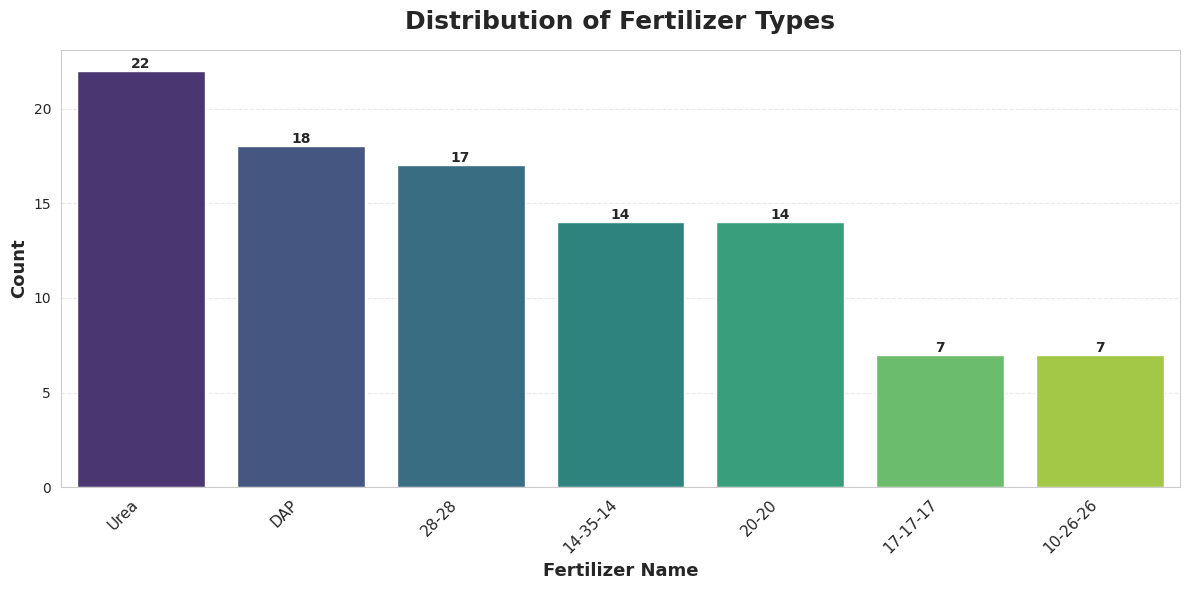

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='Fertilizer Name',
    data=df,
    palette='viridis',
    order=df['Fertilizer Name'].value_counts().index
)

plt.title(
    'Distribution of Fertilizer Types',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Fertilizer Name',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Count',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_3941/1662596395.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


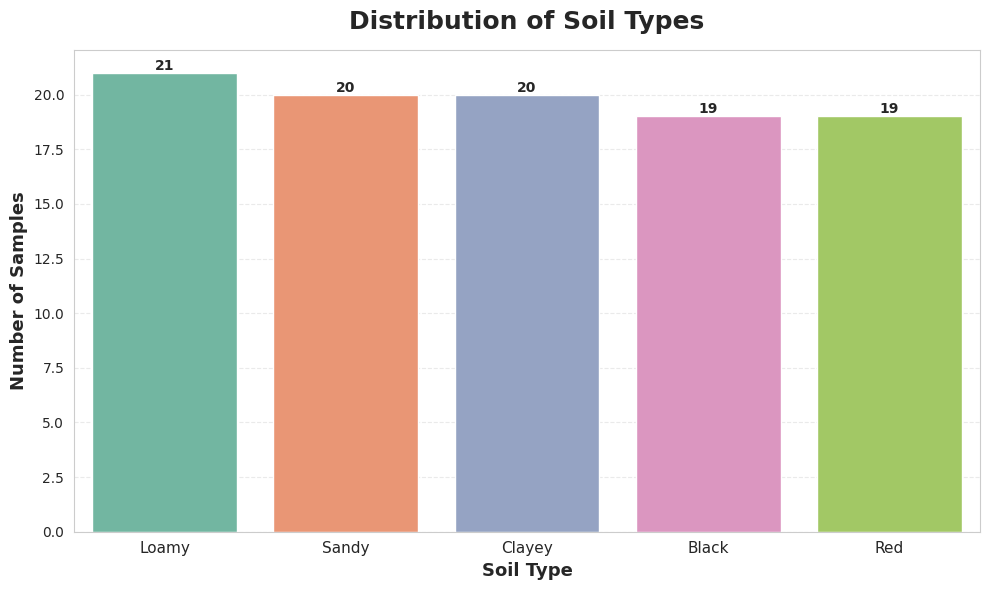

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Soil Type',
    data=df,
    palette='Set2',
    order=df['Soil Type'].value_counts().index
)

plt.title(
    'Distribution of Soil Types',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Soil Type',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Number of Samples',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(fontsize=11)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3941/62833343.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


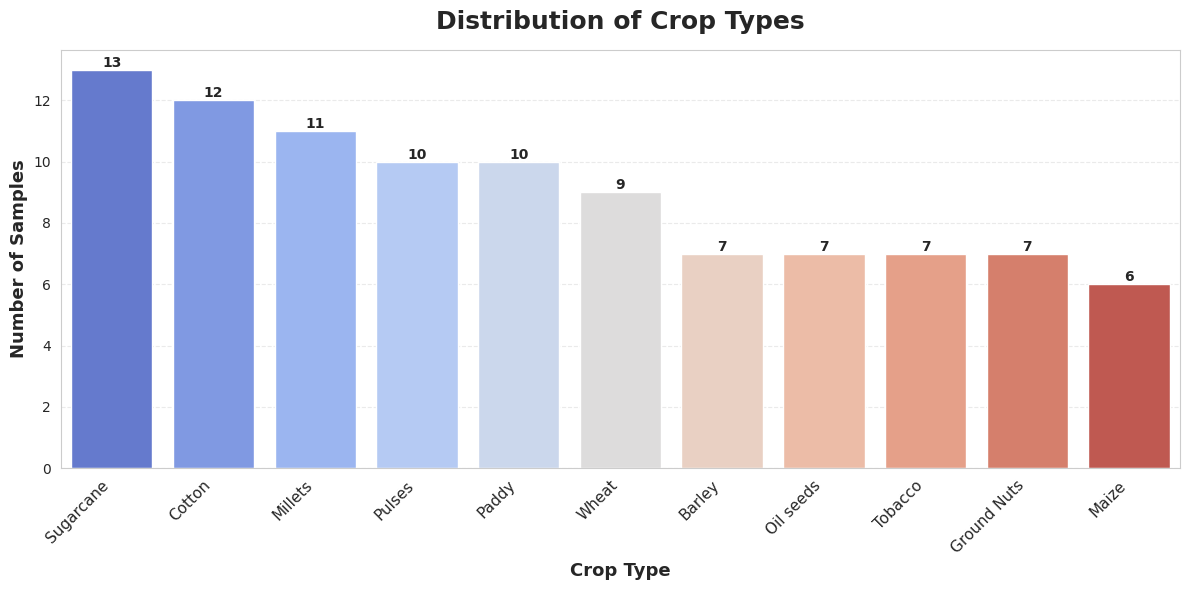

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='Crop Type',
    data=df,
    palette='coolwarm',
    order=df['Crop Type'].value_counts().index
)

plt.title(
    'Distribution of Crop Types',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Crop Type',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Number of Samples',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

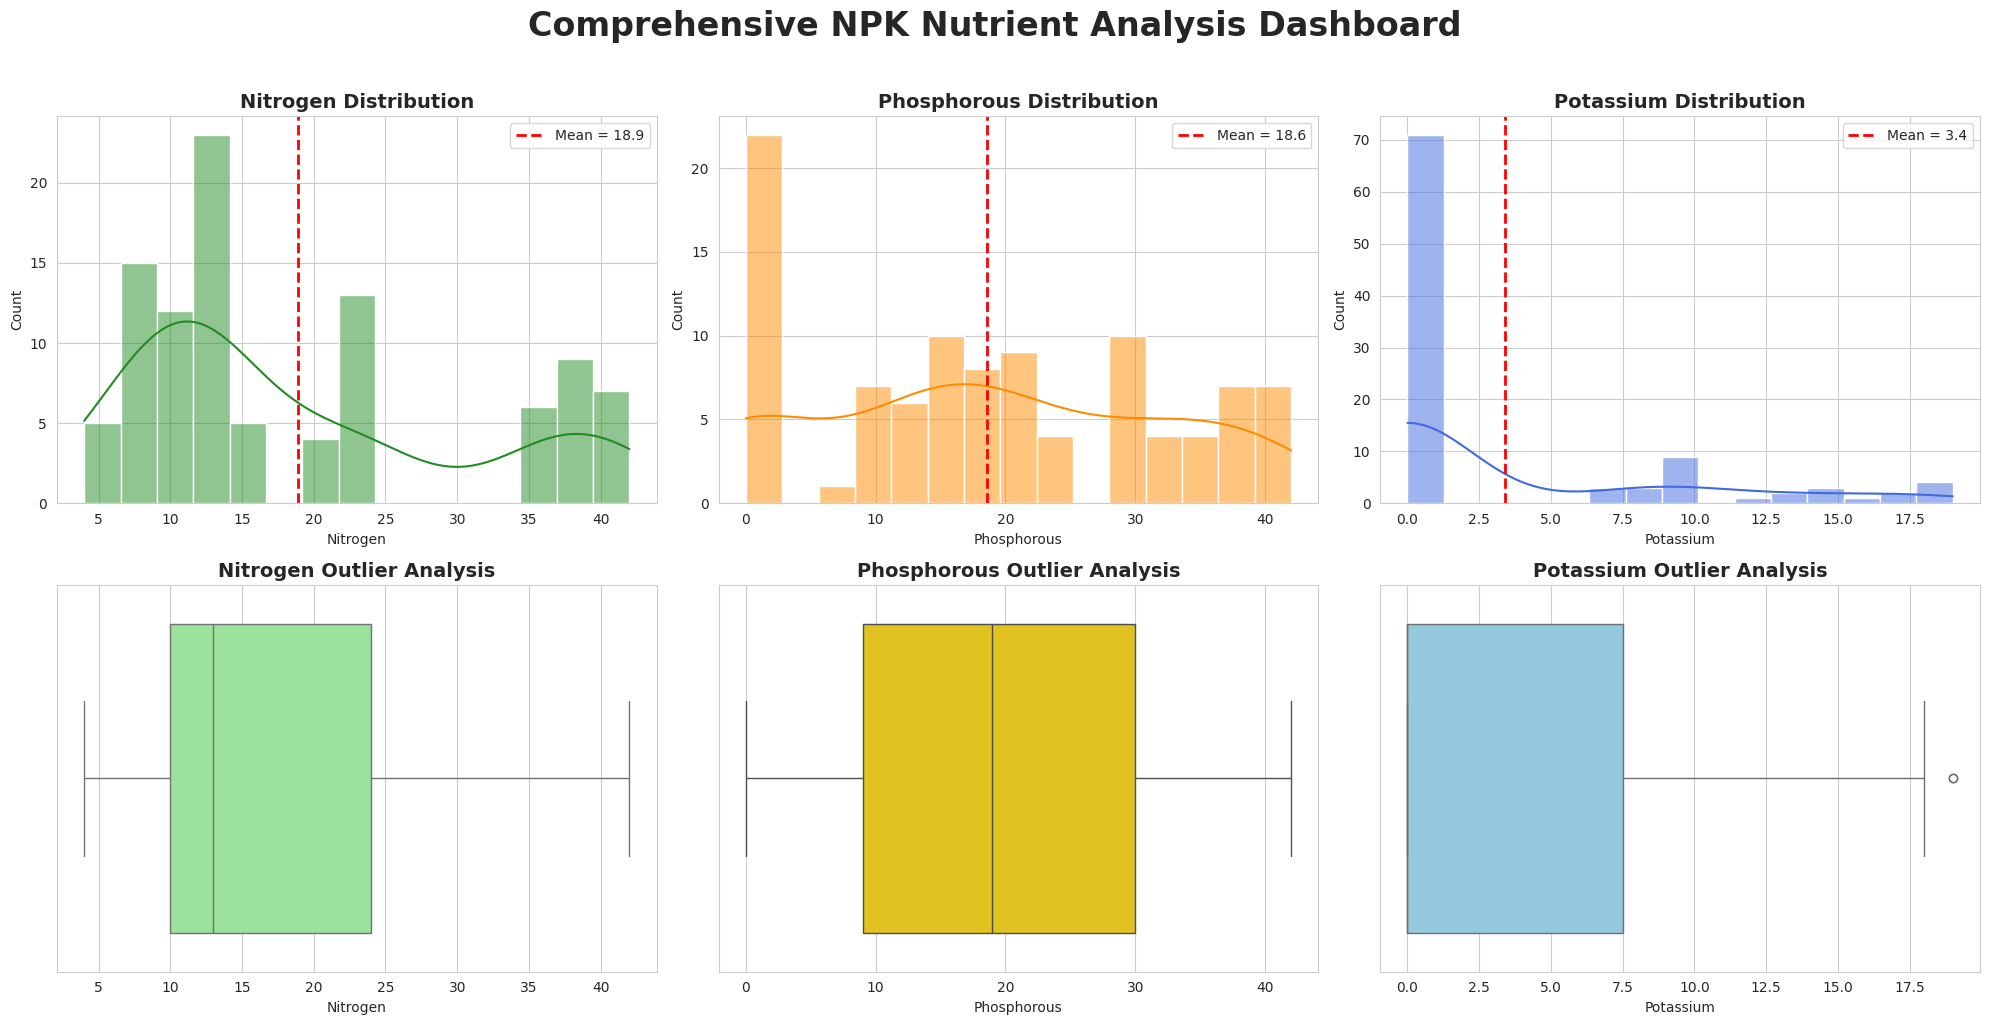

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ---------------- Nitrogen ----------------
sns.histplot(
    df['Nitrogen'],
    kde=True,
    bins=15,
    color='forestgreen',
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Nitrogen Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0,0].axvline(
    df['Nitrogen'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['Nitrogen'].mean():.1f}"
)

axes[0,0].legend()

sns.boxplot(
    x=df['Nitrogen'],
    color='lightgreen',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Nitrogen Outlier Analysis',
    fontsize=14,
    fontweight='bold'
)

# ---------------- Phosphorous ----------------
sns.histplot(
    df['Phosphorous'],
    kde=True,
    bins=15,
    color='darkorange',
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Phosphorous Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0,1].axvline(
    df['Phosphorous'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['Phosphorous'].mean():.1f}"
)

axes[0,1].legend()

sns.boxplot(
    x=df['Phosphorous'],
    color='gold',
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Phosphorous Outlier Analysis',
    fontsize=14,
    fontweight='bold'
)

# ---------------- Potassium ----------------
sns.histplot(
    df['Potassium'],
    kde=True,
    bins=15,
    color='royalblue',
    ax=axes[0,2]
)

axes[0,2].set_title(
    'Potassium Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0,2].axvline(
    df['Potassium'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['Potassium'].mean():.1f}"
)

axes[0,2].legend()

sns.boxplot(
    x=df['Potassium'],
    color='skyblue',
    ax=axes[1,2]
)

axes[1,2].set_title(
    'Potassium Outlier Analysis',
    fontsize=14,
    fontweight='bold'
)

# Dashboard Title
fig.suptitle(
    'Comprehensive NPK Nutrient Analysis Dashboard',
    fontsize=24,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [47]:
soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
fert_encoder = LabelEncoder()

df['Soil Type'] = soil_encoder.fit_transform(df['Soil Type'])

df['Crop Type'] = crop_encoder.fit_transform(df['Crop Type'])

df['Fertilizer Name'] = fert_encoder.fit_transform(
    df['Fertilizer Name']
)
print(df)
joblib.dump(soil_encoder,'soil_encoder.pkl')

joblib.dump(crop_encoder,'crop_encoder.pkl')

joblib.dump(fert_encoder,'fert_encoder.pkl')

    Temparature  Humidity   Moisture  Soil Type  Crop Type  Nitrogen  \
0            26         52        38          4          3        37   
1            29         52        45          2          8        12   
2            34         65        62          0          1         7   
3            32         62        34          3          9        22   
4            28         54        46          1          6        35   
..          ...        ...       ...        ...        ...       ...   
94           25         50        32          1          7        24   
95           30         60        27          3          9         4   
96           38         72        51          2         10        39   
97           36         60        43          4          4        15   
98           29         58        57          0          8        12   

    Potassium  Phosphorous  Fertilizer Name  
0           0            0                6  
1           0           36                5

['fert_encoder.pkl']

In [48]:
X = df.drop('Fertilizer Name', axis=1)

y = df['Fertilizer Name']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.95


In [51]:

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.85


In [52]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8


In [53]:
results = pd.DataFrame({
    'Model':[
        'Decision Tree',
        'KNN',
        'SVM'
    ],
    'Accuracy':[
        dt_acc,
        knn_acc,
        svm_acc
    ]
})

print(results)

results.sort_values(
    by='Accuracy',
    ascending=False
)

           Model  Accuracy
0  Decision Tree      0.95
1            KNN      0.85
2            SVM      0.80


,Model,Accuracy
0,Decision Tree,0.95
1,KNN,0.85
2,SVM,0.80


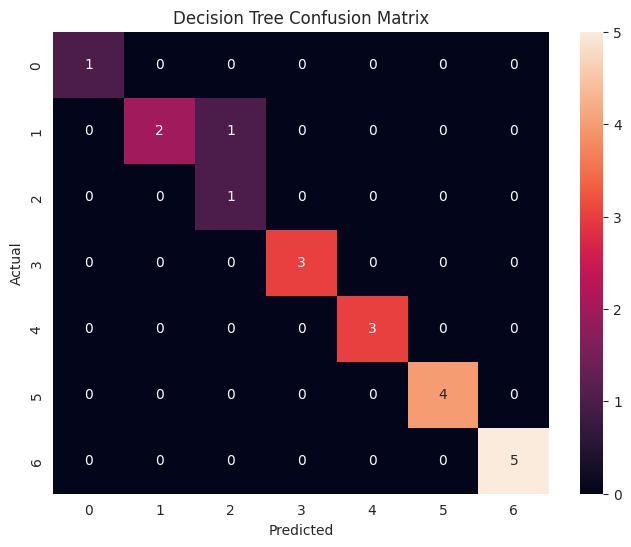

In [54]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(8,6))
sns.heatmap(dt_cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

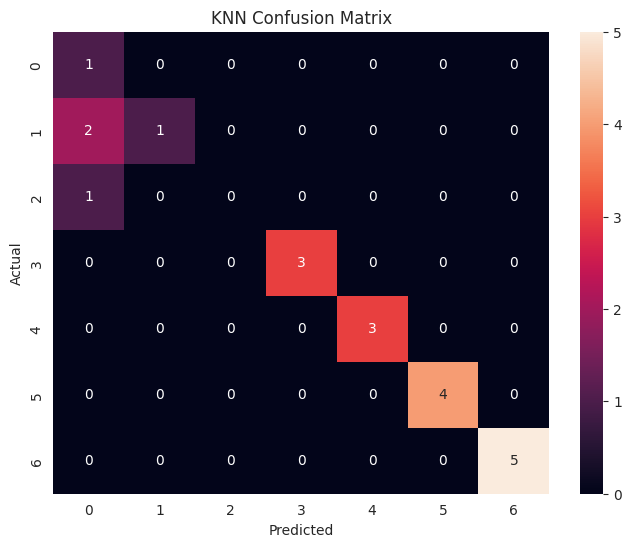

In [55]:
knn_cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(8,6))
sns.heatmap(knn_cm, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

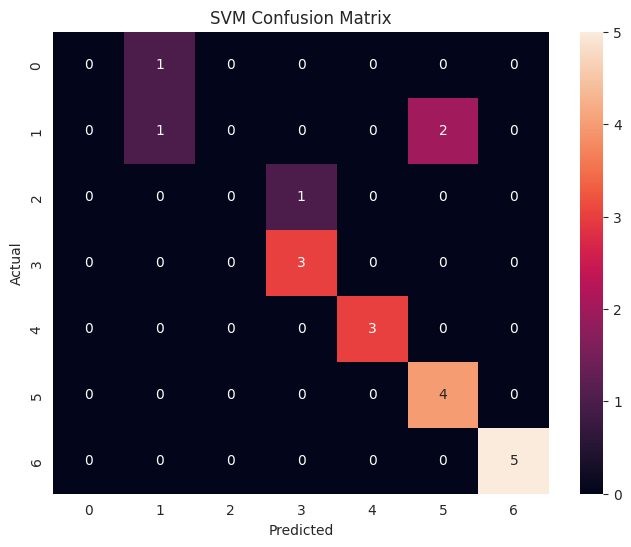

In [56]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(svm_cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
from sklearn.metrics import classification_report

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("KNN")
print(classification_report(y_test, knn_pred))

print("SVM")
print(classification_report(y_test, svm_pred))

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       0.50      1.00      0.67         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.93      0.95      0.92        20
weighted avg       0.97      0.95      0.95        20

KNN
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.33      0.50         3
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

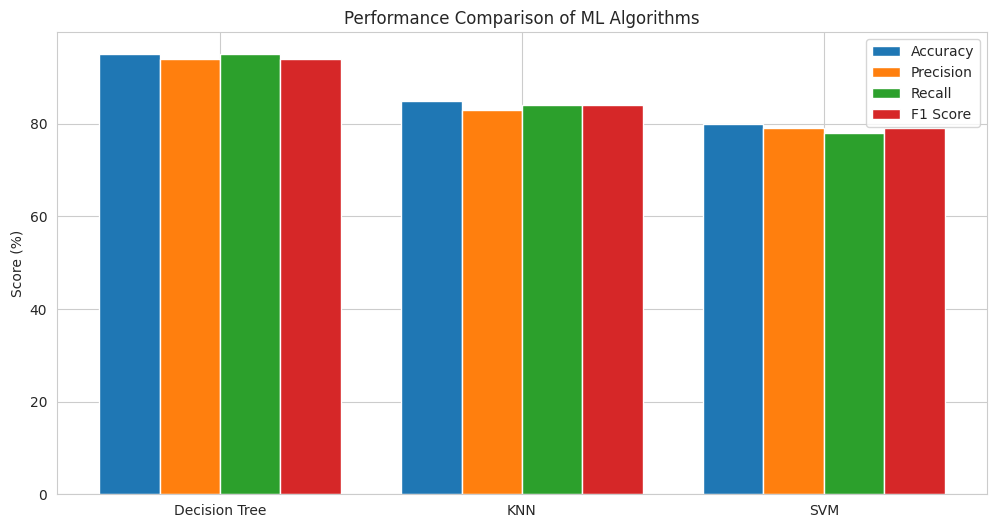

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Algorithm':['Decision Tree','KNN','SVM'],
    'Accuracy':[95,85,80],
    'Precision':[94,83,79],
    'Recall':[95,84,78],
    'F1-Score':[94,84,79]
}

df = pd.DataFrame(data)

x = np.arange(len(df['Algorithm']))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x-width*1.5, df['Accuracy'], width, label='Accuracy')
plt.bar(x-width/2, df['Precision'], width, label='Precision')
plt.bar(x+width/2, df['Recall'], width, label='Recall')
plt.bar(x+width*1.5, df['F1-Score'], width, label='F1 Score')

plt.xticks(x, df['Algorithm'])
plt.ylabel('Score (%)')
plt.title('Performance Comparison of ML Algorithms')
plt.legend()

plt.show()

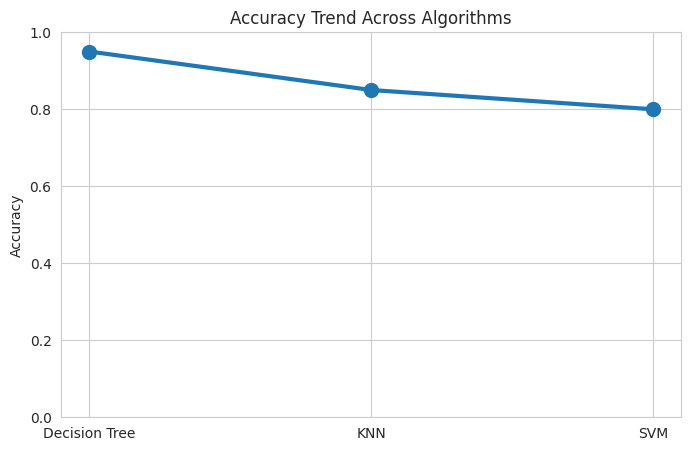

In [59]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'KNN', 'SVM']
accuracies = [dt_acc, knn_acc, svm_acc]

plt.figure(figsize=(8,5))

plt.plot(
    models,
    accuracies,
    marker='o',
    linewidth=3,
    markersize=10
)

plt.title("Accuracy Trend Across Algorithms")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.grid(True)
plt.show()

In [60]:
def predict_fertilizer(
    temperature,
    humidity,
    moisture,
    soil_type,
    crop_type,
    nitrogen,
    potassium,
    phosphorous
):

    soil_encoded = soil_encoder.transform([soil_type])[0]
    crop_encoded = crop_encoder.transform([crop_type])[0]

    sample = [[
        temperature,
        humidity,
        moisture,
        soil_encoded,
        crop_encoded,
        nitrogen,
        potassium,
        phosphorous
    ]]

    prediction = dt.predict(sample)

    fertilizer = fert_encoder.inverse_transform(prediction)



    # AI Insights
    if nitrogen < 20:
        print("⚠ Nitrogen Deficiency Detected")

    if moisture < 30:
        print("⚠ Soil Moisture is Low")

    if humidity > 80:
        print("⚠ High Humidity Condition")

    return fertilizer[0]

In [61]:
result = predict_fertilizer(
    26,        # Temperature
    81,        # Humidity
    38,        # Moisture
    'Sandy',
    'Maize',
    37,        # Nitrogen
    0,         # Potassium
    0          # Phosphorous
)

print("Recommended Fertilizer:", result)



⚠ High Humidity Condition
Recommended Fertilizer: Urea


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [62]:
df.head()

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,95,94,95,94
1,KNN,85,83,84,84
2,SVM,80,79,78,79


In [63]:
result = predict_fertilizer(
    26,
    52,
    38,
    'Sandy',
    'Maize',
    37,
    0,
    0
)

print(result)

Urea


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [64]:
import joblib

joblib.dump(dt, 'fertilizer_model.pkl')

print("Decision Tree Model Saved Successfully!")

Decision Tree Model Saved Successfully!


/tmp/ipykernel_3941/4020515342.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_3941/4020515342.py:65: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


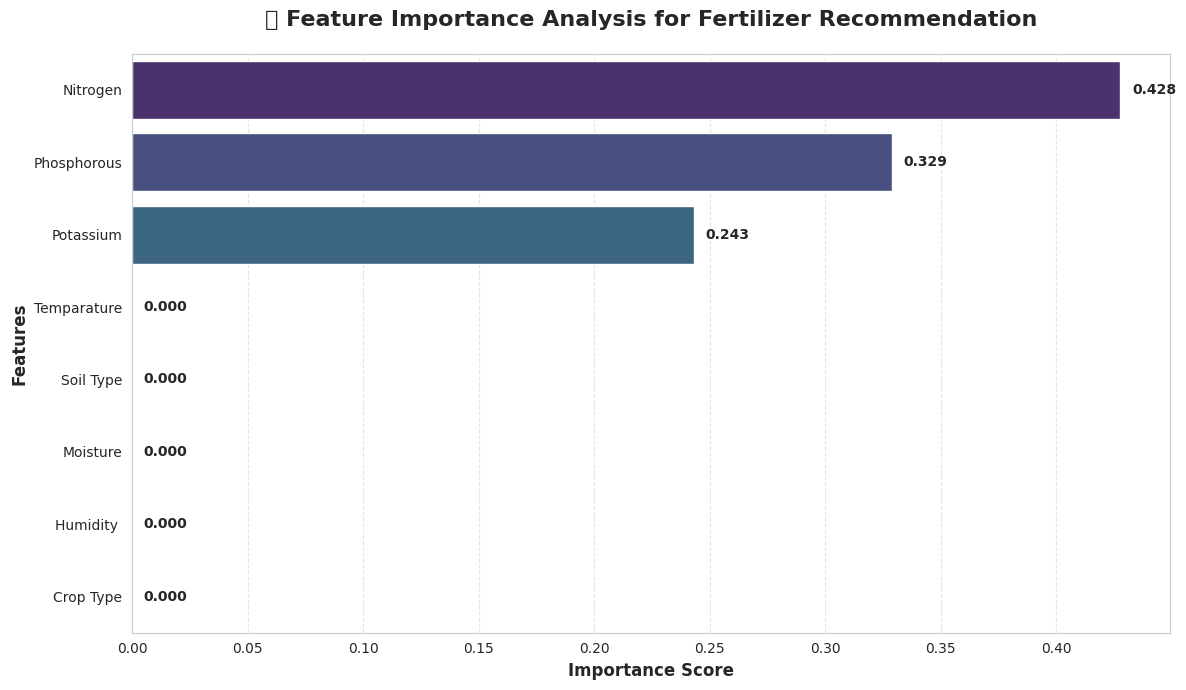

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
importance = dt.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot Style
plt.figure(figsize=(12, 7))

colors = sns.color_palette("viridis", len(feature_df))

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df,
    palette=colors
)

# Add importance values
for i, v in enumerate(feature_df['Importance']):
    ax.text(
        v + 0.005,
        i,
        f'{v:.3f}',
        va='center',
        fontweight='bold'
    )

plt.title(
    '🌱 Feature Importance Analysis for Fertilizer Recommendation',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()